In [1]:
import os
import zipfile

zip_filename = 'plantvillage.zip'
target_dir = './tomato_dataset'

# will Download only if zip doesn't exist
if not os.path.exists(zip_filename):
    print("Downloading dataset...")
    !kaggle datasets download -d mohitsingh1804/plantvillage
    print("Download complete!")
else:
    print(f"'{zip_filename}' already exists")

#Extract  only if it hasn't been extracted 
if not os.path.exists(target_dir):
    print("Extracting dataset...")
    os.makedirs(target_dir, exist_ok=True)
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(target_dir)
    print("Extracted")
else:
    print("already extracted")

'plantvillage.zip' already exists. Skipping download.
already extracted


In [3]:
import torch
import torch.nn as nn

import torchvision
from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as T
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [4]:
dataset_path = "./tomato_dataset/PlantVillage"

train_dir = f"./tomato_dataset/PlantVillage/train"

val_dir = f"./tomato_dataset/PlantVillage/val"

In [8]:
temp_transform = transforms.ToTensor()

train_dataset = datasets.ImageFolder(

    train_dir,

    transform=temp_transform

)

loader = DataLoader(train_dataset, batch_size=64, shuffle=False)

mean = 0.

std = 0.

total_images = 0

for images, _ in loader:

    batch_size = images.size(0)

    images = images.view(batch_size, images.size(1), -1)

    mean += images.mean(2).sum(0)

    std += images.std(2).sum(0)

    total_images += batch_size

mean /= total_images

std /= total_images

print("Mean:", mean)

print("Std:", std)

Mean: tensor([0.4496, 0.4651, 0.4003])
Std: tensor([0.1656, 0.1448, 0.1831])


In [9]:
transform = T.Compose([  
    T.Resize((64,64)), 
    T.ToImage(),       
    T.ToDtype(torch.float32, scale=True), 
    T.Normalize(mean.tolist(), std.tolist())
    
])


In [10]:
train_data = ImageFolder(
    root="./tomato_dataset/PlantVillage/train", 
    transform=transform
)

val_data = ImageFolder(
    root="./tomato_dataset/PlantVillage/val", 
    transform=transform
)



In [11]:
print("Training classes:", train_data.classes)
print("Number of classes:", len(train_data.classes))
print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))

Training classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Number of classes: 10
Training samples: 14529
Validation samples: 3631


In [12]:
train_loader = DataLoader(
    train_data, 
    batch_size=32, 
    shuffle=True 
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False 
)


In [14]:
hidden1 = 768
hidden2 = 512
dropout = 0.30973345545727676

learning_rate = 1.786026842336822e-05
weight_decay = 0.0009076705506388733
batch_size = 16

In [16]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")

print(device)

mps


In [17]:
class TomatoMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(3 * 64 * 64, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, 10)

        )

    def forward(self, x):
        return self.network(x)


model = TomatoMLP().to(device)

In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

In [19]:
epochs = 50

best_val_loss = float("inf")
patience = 5
counter = 0

for epoch in range(epochs):

    
    # Training
   
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

   
    # Validation
    
    model.eval()

    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, dim=1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    accuracy = 100 * correct / total

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Accuracy: {accuracy:.2f}%"
    )

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss
        counter = 0

        torch.save(model.state_dict(), "best_tomato_mlp.pth")

        print("✓ Best model saved!")

    else:

        counter += 1
        print(f"No improvement ({counter}/{patience})")

    if counter >= patience:

        print("\nEarly stopping triggered!")
        break

Epoch 1/50 | Train Loss: 1.3169 | Val Loss: 0.9746 | Val Accuracy: 68.88%
✓ Best model saved!
Epoch 2/50 | Train Loss: 0.9240 | Val Loss: 0.7692 | Val Accuracy: 75.16%
✓ Best model saved!
Epoch 3/50 | Train Loss: 0.7660 | Val Loss: 0.6694 | Val Accuracy: 79.26%
✓ Best model saved!
Epoch 4/50 | Train Loss: 0.6602 | Val Loss: 0.5988 | Val Accuracy: 80.31%
✓ Best model saved!
Epoch 5/50 | Train Loss: 0.6027 | Val Loss: 0.5654 | Val Accuracy: 81.35%
✓ Best model saved!
Epoch 6/50 | Train Loss: 0.5380 | Val Loss: 0.5279 | Val Accuracy: 82.84%
✓ Best model saved!
Epoch 7/50 | Train Loss: 0.4874 | Val Loss: 0.5039 | Val Accuracy: 82.68%
✓ Best model saved!
Epoch 8/50 | Train Loss: 0.4551 | Val Loss: 0.4919 | Val Accuracy: 83.23%
✓ Best model saved!
Epoch 9/50 | Train Loss: 0.4105 | Val Loss: 0.4764 | Val Accuracy: 83.97%
✓ Best model saved!
Epoch 10/50 | Train Loss: 0.3929 | Val Loss: 0.4607 | Val Accuracy: 84.00%
✓ Best model saved!
Epoch 11/50 | Train Loss: 0.3654 | Val Loss: 0.4505 | Val A

In [20]:
best_model = TomatoMLP().to(device)

best_model.load_state_dict(torch.load("best_tomato_mlp.pth", map_location=device))

best_model.eval()

TomatoMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=768, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.30973345545727676, inplace=False)
    (4): Linear(in_features=768, out_features=512, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.30973345545727676, inplace=False)
    (7): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [21]:
all_labels = []
all_predictions = []

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)

        _, predicted = torch.max(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 86.20%


In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

<Figure size 1000x1000 with 0 Axes>

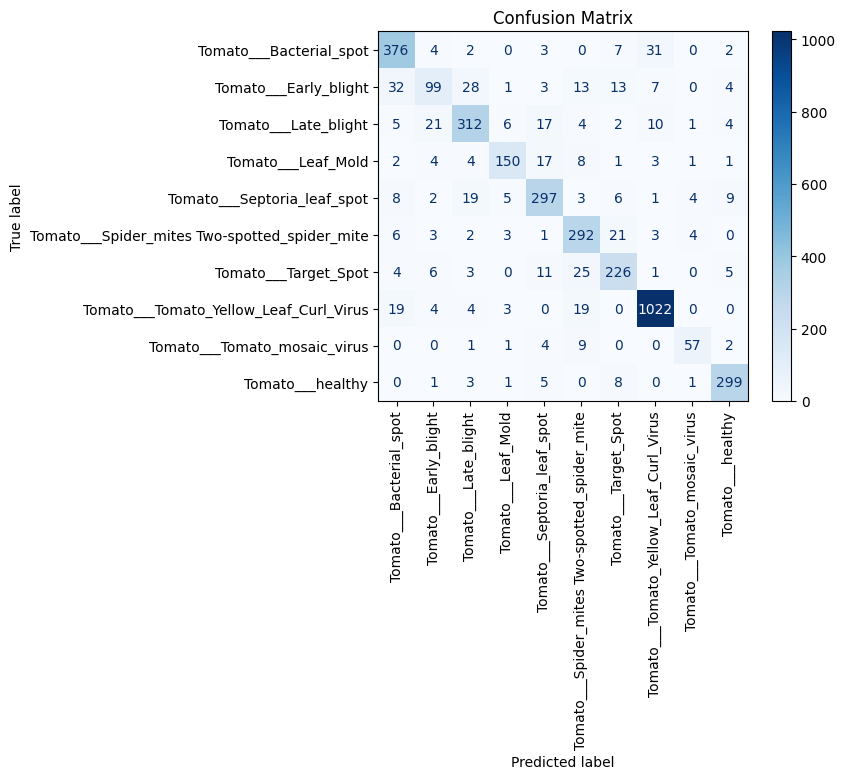

In [24]:
cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_data.classes
)

plt.figure(figsize=(10,10))
disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

In [25]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=train_data.classes
    )
)

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.83      0.88      0.86       425
                        Tomato___Early_blight       0.69      0.49      0.58       200
                         Tomato___Late_blight       0.83      0.82      0.82       382
                           Tomato___Leaf_Mold       0.88      0.79      0.83       191
                  Tomato___Septoria_leaf_spot       0.83      0.84      0.83       354
Tomato___Spider_mites Two-spotted_spider_mite       0.78      0.87      0.82       335
                         Tomato___Target_Spot       0.80      0.80      0.80       281
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.95      0.95      0.95      1071
                 Tomato___Tomato_mosaic_virus       0.84      0.77      0.80        74
                             Tomato___healthy       0.92      0.94      0.93       318

                                     accu